In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, classification_report
)
import shap
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'axes.titlesize': 12, 'axes.labelsize': 10})
C0,c1 = '#4C72B0', '#DD8452'
TARGET = 'default.payment.next.month'
SEED = 42

print('Libraries loaded successfully.')


Libraries loaded successfully.


1.0 Load Dataset using Pandas


In [2]:
try:
    df = pd.read_csv('/content/Credit_Card.csv', sep=';', on_bad_lines='warn')
except FileNotFoundError:
    print('File not found. Please check the file path.')
    raise FileNotFoundError

n_dups = df.duplicated().sum()
df = df.drop_duplicates()

print(f'Shape after deduplication: {df.shape}  (removed {n_dups} duplicates)')
print('\nColumn dtypes:')
print(df.dtypes)
print('First few rows of the dataset:')

Shape after deduplication: (31930, 30)  (removed 2858 duplicates)

Column dtypes:
ID                              int64
LIMIT_BAL                     float64
SEX                           float64
EDUCATION                     float64
MARRIAGE                      float64
AGE                           float64
PAY_0                           int64
PAY_2                           int64
PAY_3                           int64
PAY_4                           int64
PAY_5                           int64
PAY_6                           int64
BILL_AMT1                     float64
BILL_AMT2                     float64
BILL_AMT3                     float64
BILL_AMT4                     float64
BILL_AMT5                     float64
BILL_AMT6                     float64
PAY_AMT1                      float64
PAY_AMT2                      float64
PAY_AMT3                      float64
PAY_AMT4                      float64
PAY_AMT5                      float64
PAY_AMT6                      float64
defaul

In [3]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,risk_leak,BILL_AMT_SUM,LIMIT_BAL_LOG,CITY,RISK_RATING
0,1,20000.0,2.0,2.0,NaN,24.0,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,1.075.675.276.433.290,7704.0,990.353.755.128.617,City_38,2
1,2,120000.0,2.0,2.0,2.0,26.0,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,10.940.840.854.872.400,17077.0,11.695.255.355.062.700,City_6,1
2,3,90000.0,2.0,2.0,2.0,34.0,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,0.0703022492301175,101653.0,11.407.576.060.361.700,City_20,1
3,4,50000.0,2.0,2.0,1.0,37.0,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,0.058442435467177846,231334.0,10.819.798.284.210.200,City_25,1
4,5,50000.0,1.0,2.0,1.0,57.0,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,0.12943102887089503,109339.0,10.819.798.284.210.200,City_44,1


Task 1 — Exploratory Data Analysis
Objective: Understand the dataset structure, class balance, feature distributions, and correlations with the target variable.

1.1 Target Variable Distribution & Class Imbalance

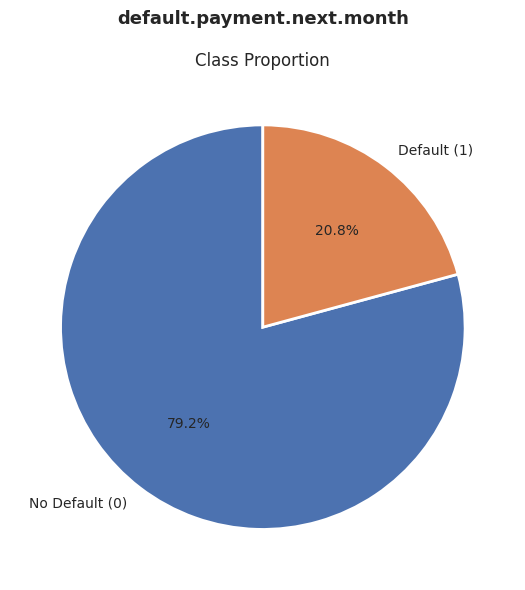

In [4]:
counts = df[TARGET].value_counts().sort_index()
labels = ['No Default (0)', 'Default (1)']


fig, ax = plt.subplots(figsize=(6,6))

ax.pie(counts.values, labels=labels, colors=[C0, c1],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(linewidth=2, edgecolor='white'),
            textprops={'fontsize': 10})
ax.set_title('Class Proportion')

##plt.suptitle('Fig 1 — Target Variable Distribution ', fontweight='bold', fontsize=13)
plt.suptitle('default.payment.next.month', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

1.2 Descriptive Statistics for Key Numerical Features

In [5]:
df['risk_leak'] = pd.to_numeric(df['risk_leak'], errors='coerce')
df['LIMIT_BAL_LOG'] = np.log1p(df['LIMIT_BAL'])
num_features = ['LIMIT_BAL', 'AGE', 'BILL_AMT_SUM','LIMIT_BAL_LOG','risk_leak']
num_features = [c for c in num_features if c in df.columns]
desc = df[num_features].describe().T[['mean', '50%', 'std', 'min', 'max']]
desc.columns = ['Mean', 'Median', 'Std Dev', 'Min', 'Max']
print('Descriptive Statistics — Key Numerical Features')
print('=' * 65)

print(desc.to_string(formatters={
    'Mean': '{:,.3f}'.format,
    'Median': '{:,.3f}'.format,
    'Std Dev': '{:,.3f}'.format,
    'Min': '{:,.3f}'.format,
    'Max': '{:,.3f}'.format
}))

Descriptive Statistics — Key Numerical Features
                     Mean      Median     Std Dev          Min            Max
LIMIT_BAL     183,757.931 140,000.000 233,103.327   10,000.000  5,600,000.000
AGE                35.499      34.000       9.222       21.000         79.000
BILL_AMT_SUM  295,187.496 128,431.000 569,057.861 -336,259.000 21,292,660.000
LIMIT_BAL_LOG      11.693      11.849       0.968        9.210         15.538
risk_leak           0.106       0.016       0.310       -0.385          1.000


1.3 Histograms — Distributions of Numerical Features

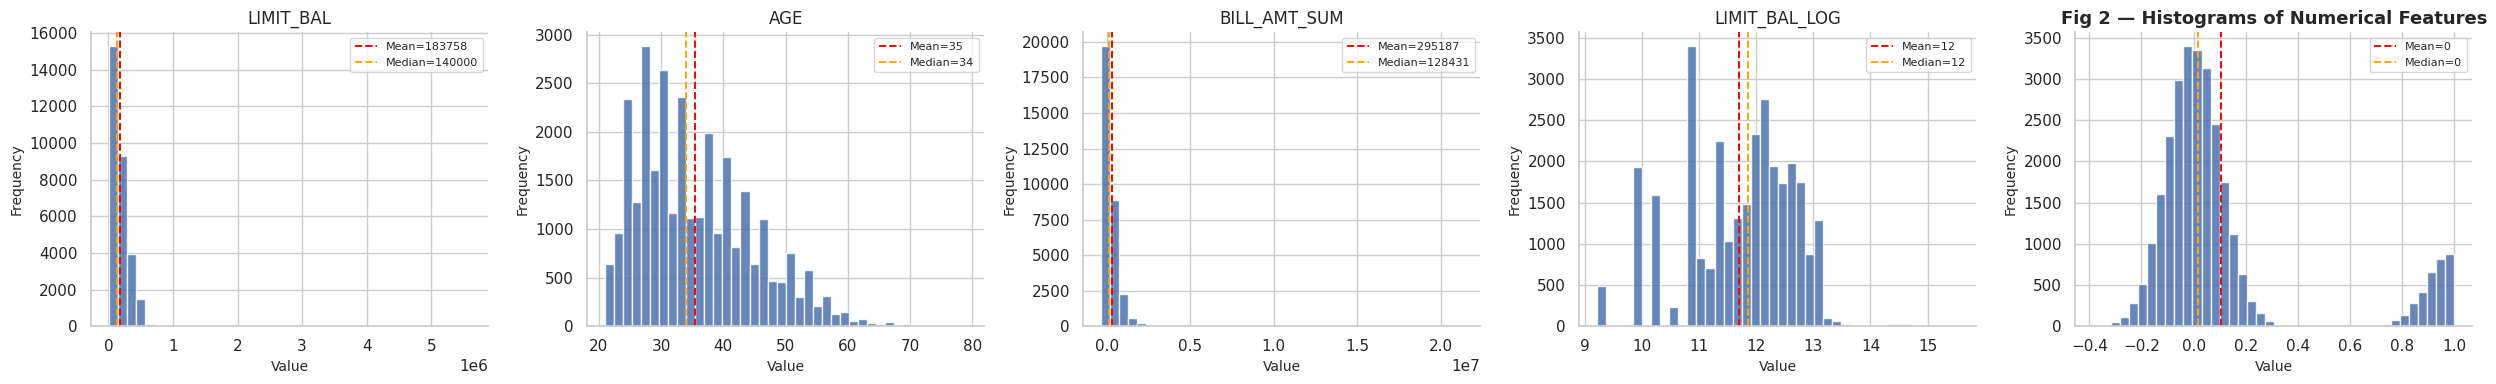

In [8]:
fig, axes = plt.subplots(1, len(num_features), figsize=(5 * len(num_features), 4))

if len(num_features) == 1:
    axes = [axes]


for ax, col in zip(axes, num_features):
    data = pd.to_numeric(df[col], errors='coerce').dropna()
    ax.hist(data, bins=40, color=C0, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.4, label=f'Mean={data.mean():.0f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.4, label=f'Median={data.median():.0f}')
    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

plt.title('Fig 2 — Histograms of Numerical Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig2_histograms.png', dpi=150, bbox_inches='tight')
plt.show()


1.4 Box Plots — Numerical Features by Default Status

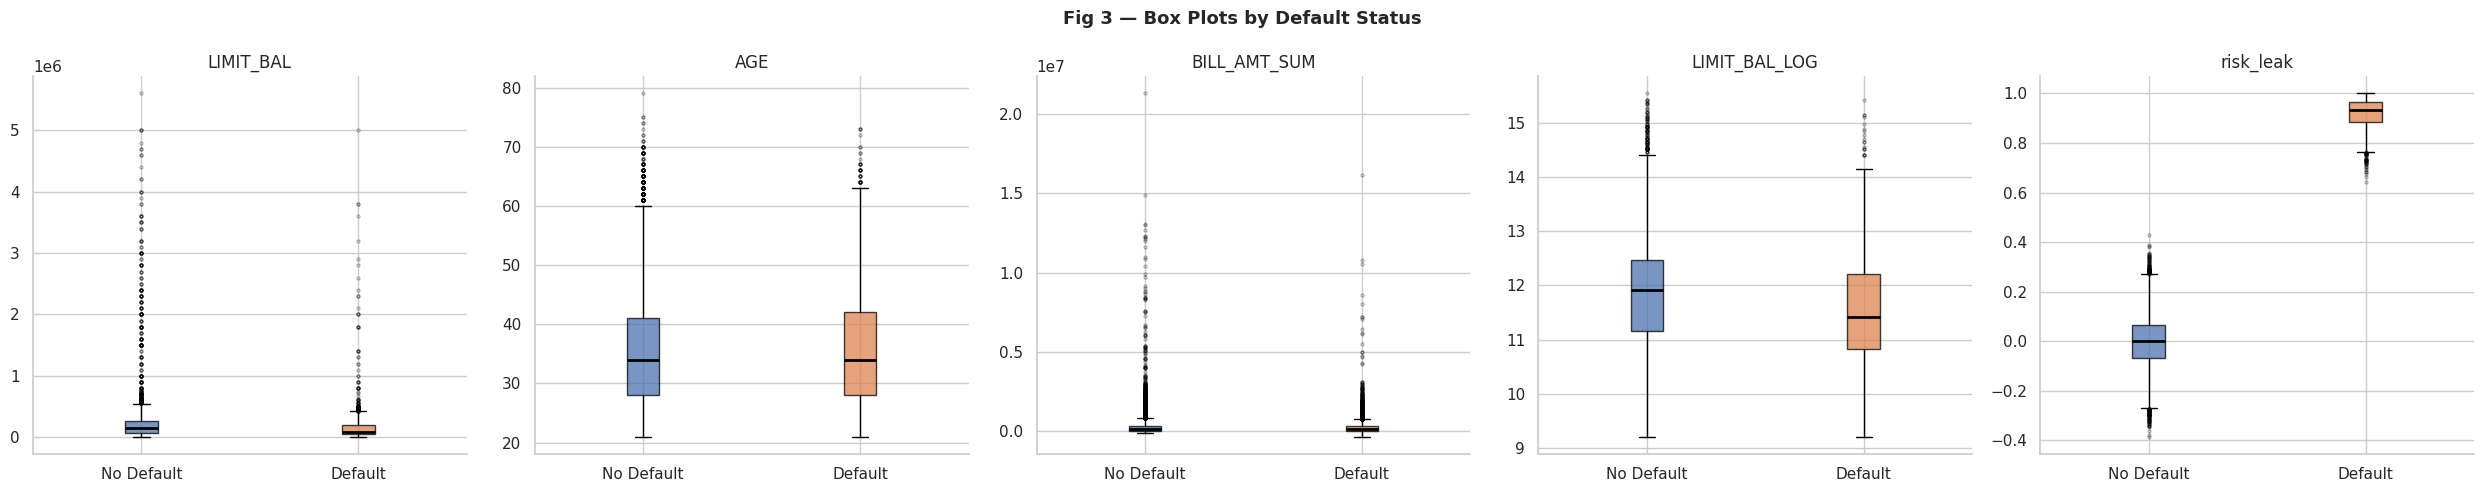

In [9]:
fig, axes = plt.subplots(1, len(num_features), figsize=(5 * len(num_features), 5))
if len(num_features) == 1:
    axes = [axes]

for ax,col in zip(axes,num_features):
  data_0=pd.to_numeric(df.loc[df[TARGET]==0,col],errors='coerce').dropna()
  data_1=pd.to_numeric(df.loc[df[TARGET]==1,col],errors='coerce').dropna()
  if not data_0.empty and not data_1.empty:
    bp=ax.boxplot([data_0,data_1],patch_artist=True,
                  medianprops=dict(color='black',linewidth=2),
                  flierprops=dict(marker='o',markersize=2,alpha=0.3))
    for patch,color in zip(bp['boxes'],[C0,c1]):
      patch.set_facecolor(color)
      patch.set_alpha(0.75)
  ax.set_xticks([1,2])
  ax.set_xticklabels(['No Default','Default'])
  ax.set_title(col)
  ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Fig 3 — Box Plots by Default Status', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig3_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

1.5 Categorical Features — Distribution and Default Rate

--- Categorical Distributions (Value Counts) ---

Distribution for Feature: SEX
     Count  Percentage (%)
SEX                       
2.0  18315           57.36
1.0  12008           37.61
NaN   1607            5.03

Distribution for Feature: EDUCATION
           Count  Percentage (%)
EDUCATION                       
2.0        14150           44.32
1.0        10707           33.53
3.0         4993           15.64
NaN         1600            5.01
5.0          285            0.89
4.0          130            0.41
6.0           50            0.16
0.0           15            0.05

Distribution for Feature: MARRIAGE
          Count  Percentage (%)
MARRIAGE                       
2.0       16128           50.51
1.0       13841           43.35
NaN        1586            4.97
3.0         324            1.01
0.0          51            0.16

Distribution for Feature: CITY
         Count  Percentage (%)
CITY                          
City_47    706            2.21
City_3     682            2.14
Ci

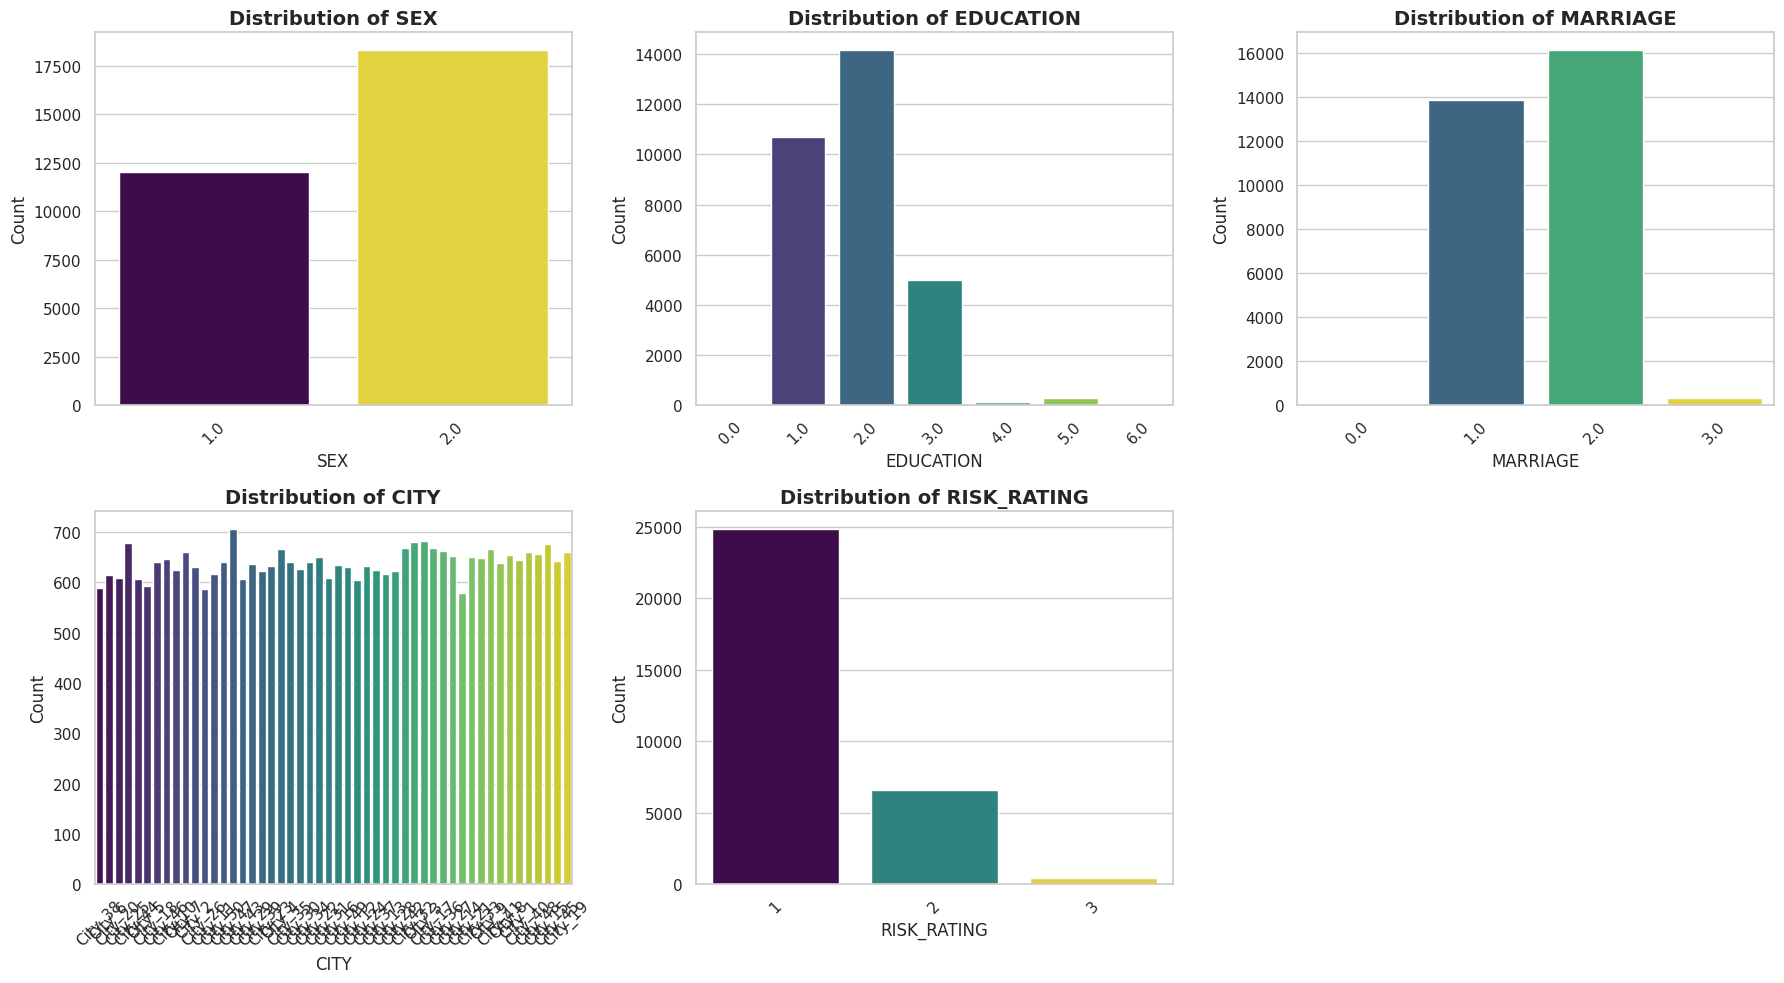

In [10]:
categorical_features = ['SEX', 'EDUCATION', 'MARRIAGE', 'CITY', 'RISK_RATING']
print("--- Categorical Distributions (Value Counts) ---")
for col in categorical_features:
    if col in df.columns:
        print(f"\nDistribution for Feature: {col}")
        counts = df[col].value_counts(dropna=False)
        percentages = df[col].value_counts(normalize=True, dropna=False) * 100


        summary = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages.round(2)})
        print(summary)
    else:
        print(f"\nWarning: Column '{col}' not found in the DataFrame.")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    if col in df.columns:
        sns.countplot(data=df, x=col, ax=axes[i], palette="viridis", hue=col, legend=False)
        axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Count', fontsize=12)
        axes[i].tick_params(axis='x', rotation=45)
    else:
        axes[i].axis('off')

if len(categorical_features) < len(axes):
    axes[-1].axis('off')

plt.tight_layout()
plt.savefig(f'fig4_categorical_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

1.6 Correlation Heatmap

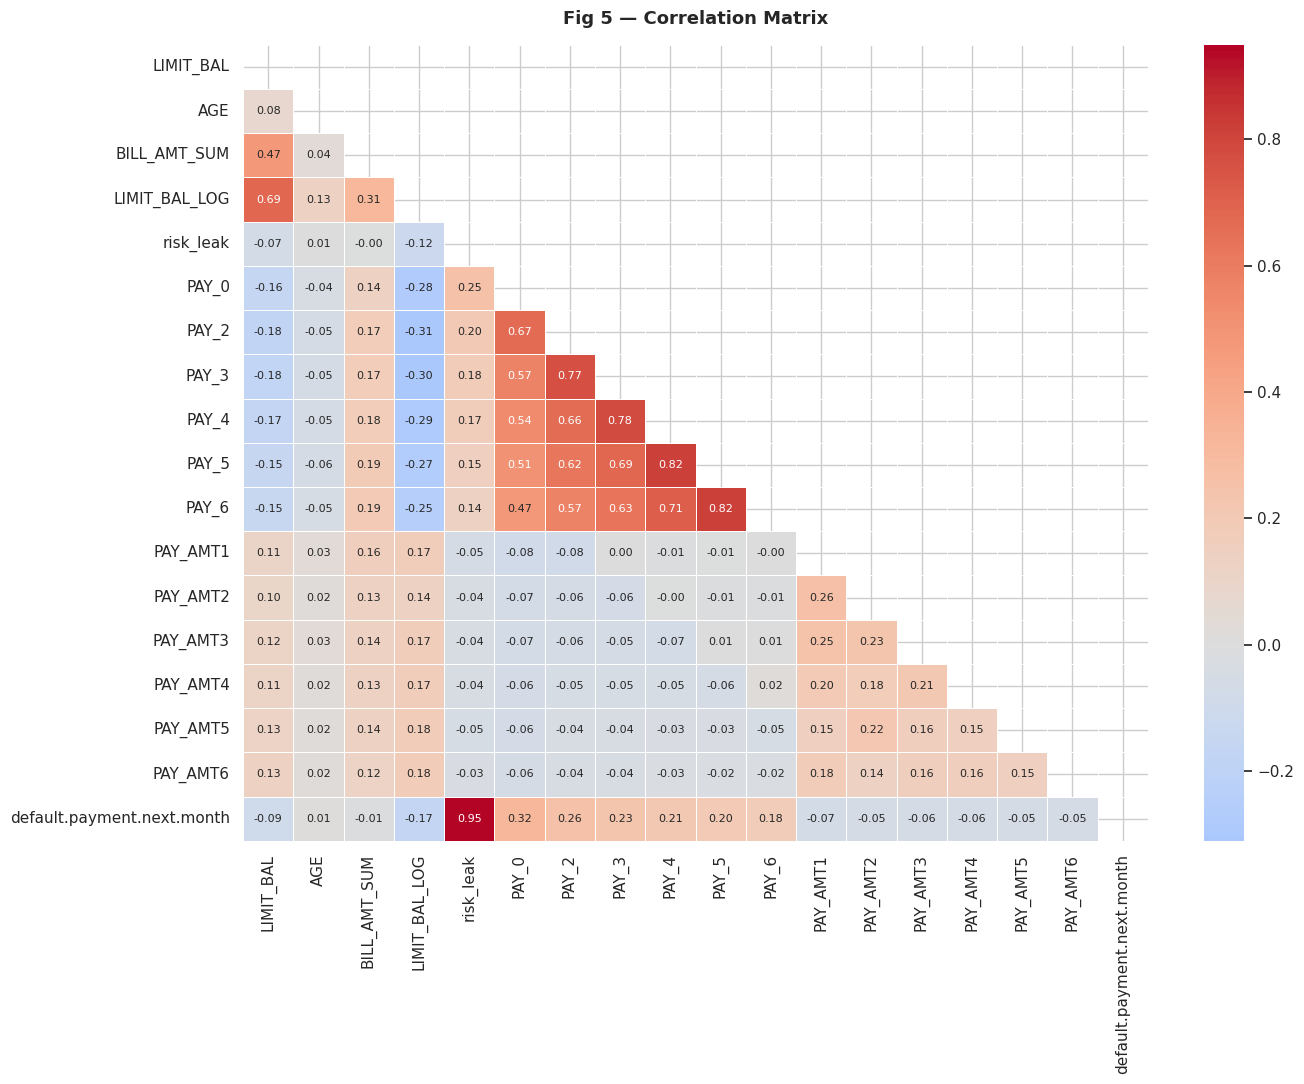


Top 10 features correlated with target:
risk_leak        0.9496
PAY_0            0.3206
PAY_2            0.2596
PAY_3            0.2311
PAY_4            0.2131
PAY_5            0.2008
PAY_6            0.1831
LIMIT_BAL_LOG    0.1664
LIMIT_BAL        0.0933
PAY_AMT1         0.0715


In [11]:
pay_cols  = [c for c in df.columns if c.startswith('PAY_')]
corr_cols = num_features + pay_cols + [TARGET]
corr_cols = [c for c in corr_cols if c in df.columns]

df_corr = df[corr_cols].copy()
for col in corr_cols:
    df_corr[col] = pd.to_numeric(df_corr[col], errors='coerce')

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size': 8})
ax.set_title('Fig 5 — Correlation Matrix', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('fig5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print('\nTop 10 features correlated with target:')
target_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(target_corr.head(10).round(4).to_string())

Task 2 — Data Preparation
Objective: Handle missing values, encode categoricals, remove leakage features, and scale numerical variables.

In [12]:
df_clean = df.copy()

missing = df_clean.isnull().sum()
missing = missing[missing > 0]
print(f'Total columns with missing values: {len(missing)}')
print(missing.to_frame(name='Missing Count').assign(
    Pct=lambda x: (x['Missing Count'] / len(df_clean) * 100).round(2)
))

for col in missing.index:
    if df_clean[col].dtype in ['float64', 'int64', 'int32', 'float32']:

        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  [{col}] numerical  → median imputation ({median_val:.3f})')
    else:

        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f'  [{col}] categorical → mode imputation ("{mode_val}")')

print(f'\nRemaining missing values after imputation: {df_clean.isnull().sum().sum()}')

Total columns with missing values: 9
               Missing Count    Pct
LIMIT_BAL               1582   4.95
SEX                     1607   5.03
EDUCATION               1600   5.01
MARRIAGE                1586   4.97
AGE                     1604   5.02
PAY_AMT1                1585   4.96
PAY_AMT2                1608   5.04
risk_leak               3371  10.56
LIMIT_BAL_LOG           1582   4.95
  [LIMIT_BAL] numerical  → median imputation (140000.000)
  [SEX] numerical  → median imputation (2.000)
  [EDUCATION] numerical  → median imputation (2.000)
  [MARRIAGE] numerical  → median imputation (2.000)
  [AGE] numerical  → median imputation (34.000)
  [PAY_AMT1] numerical  → median imputation (2121.000)
  [PAY_AMT2] numerical  → median imputation (2011.000)
  [risk_leak] numerical  → median imputation (0.016)
  [LIMIT_BAL_LOG] numerical  → median imputation (11.849)

Remaining missing values after imputation: 0


Justification: Median imputation is preferred over mean for numerical columns because the dataset contains skewed distributions (visible in the histograms above) and outliers. For categorical columns, mode imputation preserves the most common category without introducing artificial values.

2.2 Remove Leakage and Non-Predictive Columns

In [13]:
drop_cols = [c for c in ['ID', 'risk_leak'] if c in df_clean.columns]
df_clean.drop(columns=drop_cols, inplace=True)
print(f'Dropped columns (leakage / ID): {drop_cols}')
print(f'Remaining features: {df_clean.shape[1] - 1} + target')

Dropped columns (leakage / ID): ['ID', 'risk_leak']
Remaining features: 27 + target


2.3 Encode Categorical Variables

In [14]:
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [c for c in cat_cols if c != TARGET]
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    before_sample = df_clean[col].value_counts().head(3).to_dict()
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f'  Encoded [{col}] — example mapping: {before_sample} → integers')

print('\nAll columns are now numeric.')

Categorical columns to encode: ['CITY']
  Encoded [CITY] — example mapping: {'City_47': 706, 'City_3': 682, 'City_32': 680} → integers

All columns are now numeric.


2.4 Feature / Target Split and Train-Test Split

In [15]:
X = df_clean.drop(columns=[TARGET])
y = df_clean[TARGET]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training set : {X_train.shape[0]:,} rows  |  Default rate: {y_train.mean():.3f}')
print(f'Test set     : {X_test.shape[0]:,} rows  |  Default rate: {y_test.mean():.3f}')
print(f'Features     : {X_train.shape[1]}')

Training set : 25,544 rows  |  Default rate: 0.208
Test set     : 6,386 rows  |  Default rate: 0.208
Features     : 27


2.5 Feature Scaling (StandardScaler)

In [16]:
for col in X_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling example — first feature (LIMIT_BAL):')
print(f'  Before scaling — mean: {X_train.iloc[:,0].mean():.1f},  std: {X_train.iloc[:,0].std():.1f}')
print(f'  After  scaling — mean: {X_train_sc[:,0].mean():.4f},  std: {X_train_sc[:,0].std():.4f}')
print('\nStandardScaler centres each feature (mean=0, std=1), ensuring distance-based')
print('models (KNN, SVM) are not dominated by features with large numerical ranges.')

Scaling example — first feature (LIMIT_BAL):
  Before scaling — mean: 181992.6,  std: 226052.5
  After  scaling — mean: -0.0000,  std: 1.0000

StandardScaler centres each feature (mean=0, std=1), ensuring distance-based
models (KNN, SVM) are not dominated by features with large numerical ranges.


Task 3 — Model Training
Objective: Train five classification algorithms and record initial hyperparameters.



In [17]:
# ── 3.1  Define classifiers with default hyperparameters ──────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, random_state=SEED, n_jobs=-1, class_weight='balanced'
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, random_state=SEED
    ),
    'K-Nearest Neighbors': KNeighborsClassifier(
        n_neighbors=5, n_jobs=-1
    ),
    'SVM': SVC(
        probability=True, random_state=SEED, class_weight='balanced'
    ),
}

print('Initial hyperparameters (before any tuning):')
print('=' * 60)
for name, clf in models.items():
    print(f'\n{name}:')
    for k, v in clf.get_params().items():
        print(f'   {k}: {v}')

Initial hyperparameters (before any tuning):

Logistic Regression:
   C: 1.0
   class_weight: balanced
   dual: False
   fit_intercept: True
   intercept_scaling: 1
   l1_ratio: None
   max_iter: 1000
   multi_class: deprecated
   n_jobs: None
   penalty: l2
   random_state: 42
   solver: lbfgs
   tol: 0.0001
   verbose: 0
   warm_start: False

Decision Tree:
   ccp_alpha: 0.0
   class_weight: None
   criterion: gini
   max_depth: None
   max_features: None
   max_leaf_nodes: None
   min_impurity_decrease: 0.0
   min_samples_leaf: 1
   min_samples_split: 2
   min_weight_fraction_leaf: 0.0
   monotonic_cst: None
   random_state: 42
   splitter: best

Random Forest:
   bootstrap: True
   ccp_alpha: 0.0
   class_weight: balanced
   criterion: gini
   max_depth: None
   max_features: sqrt
   max_leaf_nodes: None
   max_samples: None
   min_impurity_decrease: 0.0
   min_samples_leaf: 1
   min_samples_split: 2
   min_weight_fraction_leaf: 0.0
   monotonic_cst: None
   n_estimators: 100
   n_

In [18]:
trained = {}
for name, clf in models.items():
    print(f'Training {name}...', end='  ')
    clf.fit(X_train_sc, y_train)
    trained[name] = clf
    print('Done.')

print('\nAll models trained.')

Training Logistic Regression...  Done.
Training Decision Tree...  Done.
Training Random Forest...  Done.
Training Gradient Boosting...  Done.
Training K-Nearest Neighbors...  Done.
Training SVM...  Done.

All models trained.


Task 4 — Model Evaluation and Visualisation
Objective: Compare models using multiple metrics, visualise diagnostics, tune the best model, and interpret predictions with SHAP.

4.1 Comparative Performance Table

Model Performance Comparison (sorted by AUC-ROC)
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Random Forest          0.8284     0.6995  0.3052    0.4250   0.8038
Gradient Boosting      0.8240     0.6460  0.3384    0.4441   0.7739
SVM                    0.7770     0.4700  0.5720    0.5160   0.7598
Logistic Regression    0.7706     0.4574  0.5576    0.5025   0.7387
K-Nearest Neighbors    0.8027     0.5427  0.3210    0.4034   0.7023
Decision Tree          0.7726     0.4465  0.3934    0.4183   0.6327


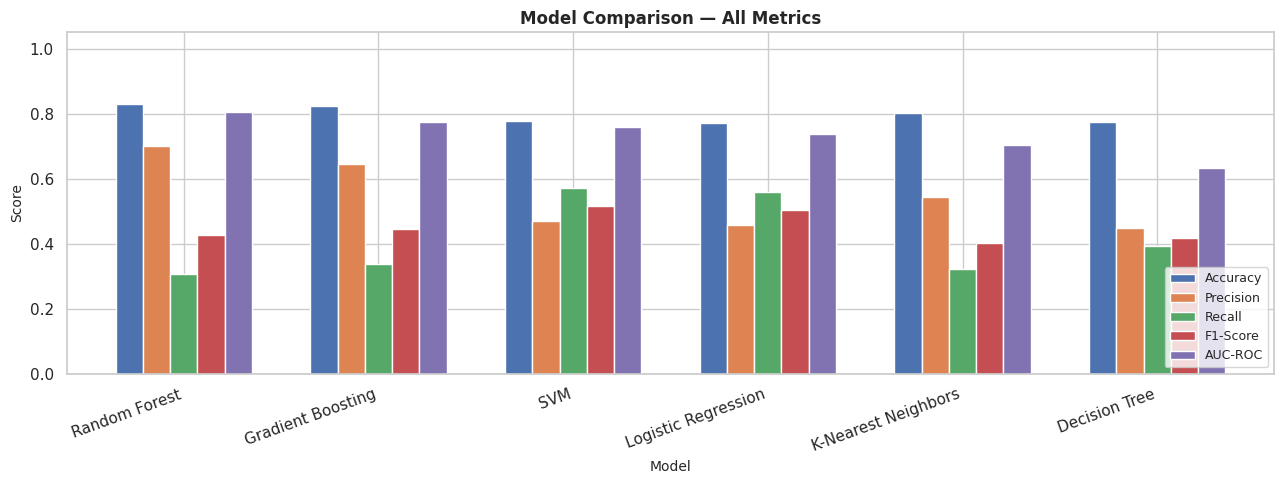

In [19]:
rows = []
for name, clf in trained.items():
    y_pred = clf.predict(X_test_sc)
    y_prob = clf.predict_proba(X_test_sc)[:, 1]
    rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
    })

results_df = pd.DataFrame(rows).set_index('Model').sort_values('AUC-ROC', ascending=False)

# Styled table
print('Model Performance Comparison (sorted by AUC-ROC)')
print('=' * 75)
print(results_df.round(4).to_string())

# Also plot the comparison as a bar chart
results_df[['Accuracy','Precision','Recall','F1-Score','AUC-ROC']].plot(
    kind='bar', figsize=(13, 5), width=0.7,
    color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
)
plt.title('Model Comparison — All Metrics', fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

4.2 Confusion Matrices

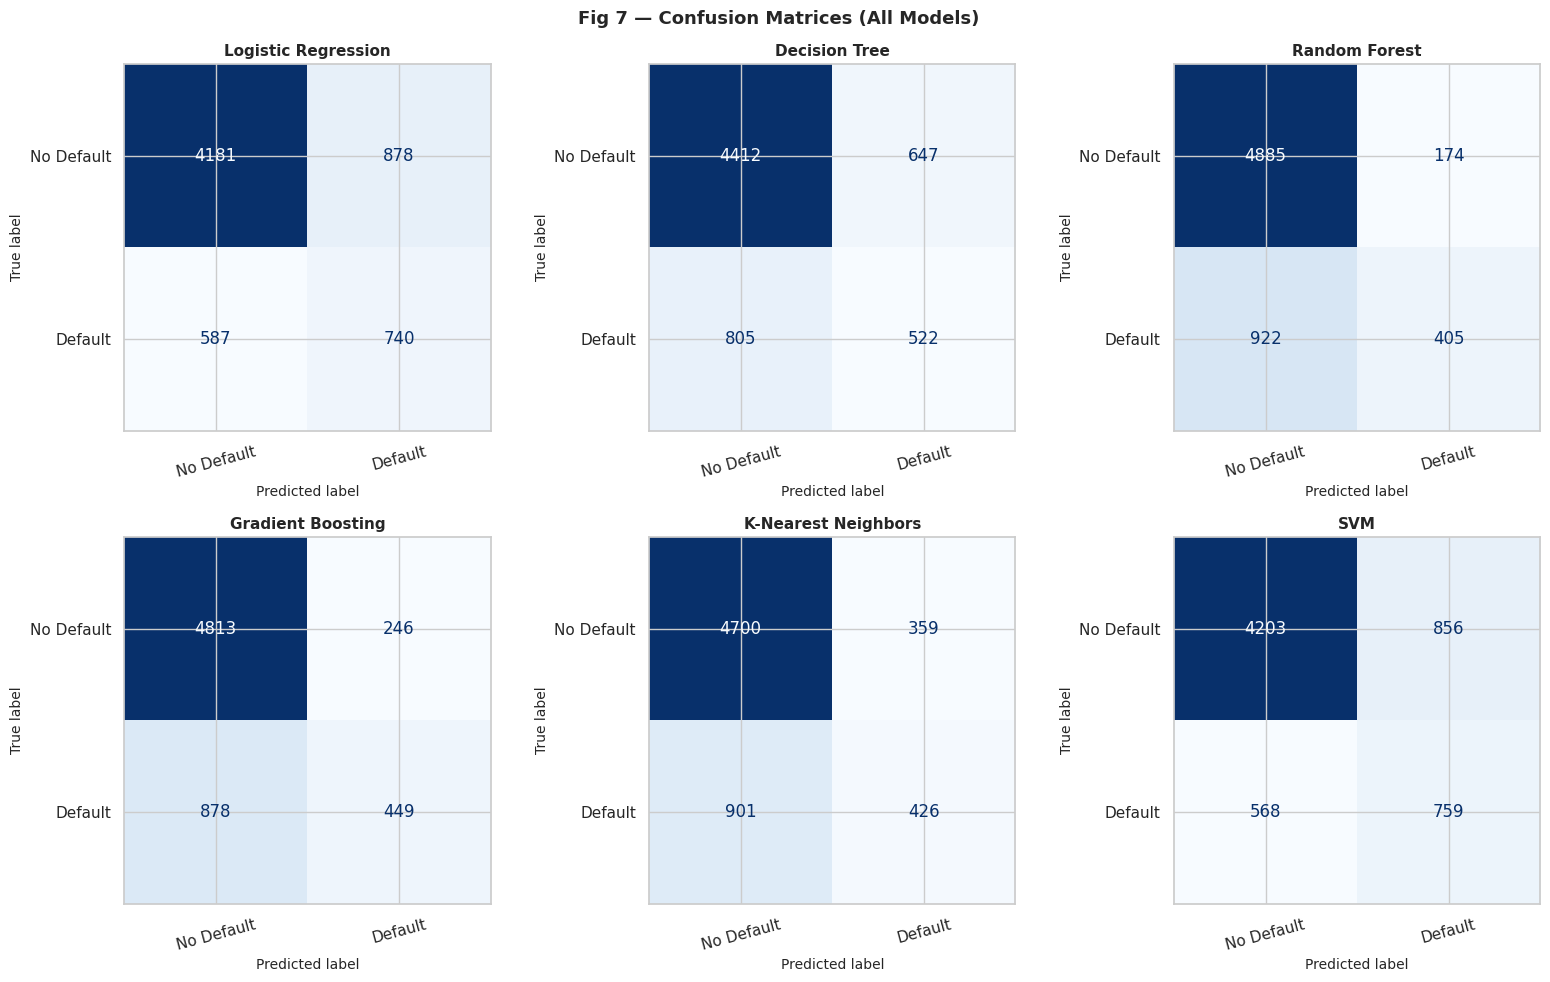

In [20]:
n = len(trained)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, clf) in zip(axes, trained.items()):
    y_pred = clf.predict(X_test_sc)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', labelrotation=15)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Fig 7 — Confusion Matrices (All Models)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

4.3 ROC Curves

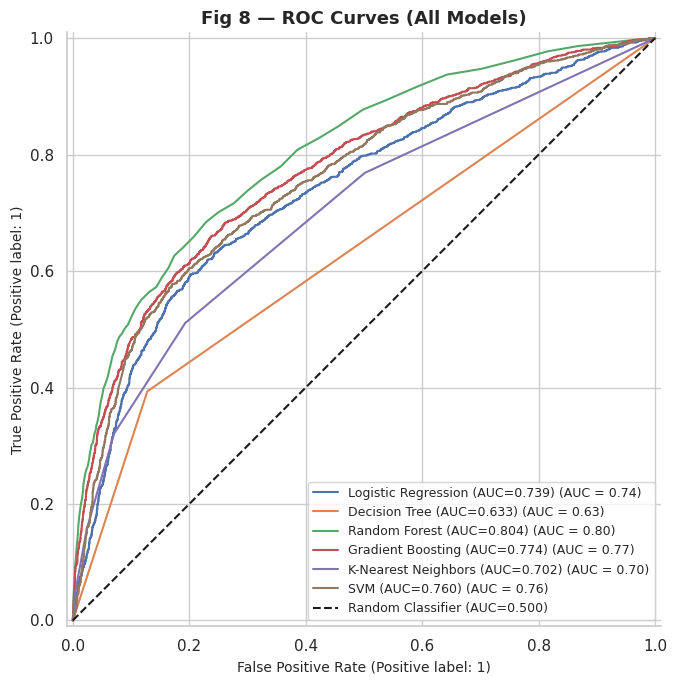

In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']
for (name, clf), color in zip(trained.items(), colors):
    y_prob = clf.predict_proba(X_test_sc)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    RocCurveDisplay.from_predictions(
        y_test, y_prob, name=f'{name} (AUC={auc:.3f})', ax=ax, color=color
    )

ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC=0.500)')
ax.set_title('Fig 8 — ROC Curves (All Models)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

4.4 Hyperparameter Tuning — Best Model Random Forest

In [22]:
best_model_name = results_df.index[0]
print(f'Best model by AUC-ROC before tuning: {best_model_name}')
print(f'  AUC-ROC = {results_df.loc[best_model_name, "AUC-ROC"]:.4f}')
print(f'  F1-Score = {results_df.loc[best_model_name, "F1-Score"]:.4f}')

Best model by AUC-ROC before tuning: Random Forest
  AUC-ROC = 0.8038
  F1-Score = 0.4250


In [23]:
param_distributions = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 5, 10, 20],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced', 'balanced_subsample'],
}

tuner = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='roc_auc',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

tuner.fit(X_train_sc, y_train)

print(f'\nBest parameters found:')
for k, v in tuner.best_params_.items():
    print(f'   {k}: {v}')
print(f'\nBest CV AUC-ROC: {tuner.best_score_:.4f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters found:
   n_estimators: 200
   min_samples_split: 2
   min_samples_leaf: 4
   max_features: log2
   max_depth: 20
   class_weight: balanced_subsample

Best CV AUC-ROC: 0.7793


Random Forest — Before vs After Tuning
               Accuracy  Precision  Recall  F1-Score  AUC-ROC
Stage                                                        
Before Tuning    0.8284     0.6995  0.3052    0.4250   0.8038
After Tuning     0.8143     0.5630  0.4748    0.5151   0.7898


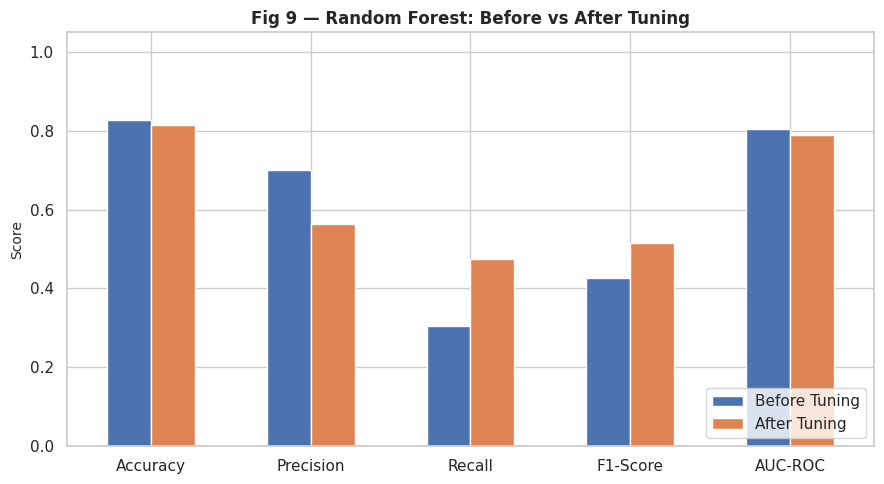

In [26]:
best_before = trained['Random Forest']
best_after  = tuner.best_estimator_

comparison_rows = []
for label, clf in [('Before Tuning', best_before), ('After Tuning', best_after)]:
    y_pred = clf.predict(X_test_sc)
    y_prob = clf.predict_proba(X_test_sc)[:, 1]
    comparison_rows.append({
        'Stage'    : label,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall'   : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score' : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'  : roc_auc_score(y_test, y_prob),
    })

cmp_df = pd.DataFrame(comparison_rows).set_index('Stage')
print('Random Forest — Before vs After Tuning')
print('=' * 65)
print(cmp_df.round(4).to_string())

# Plot comparison
cmp_df.T.plot(kind='bar', figsize=(9, 5), color=[C0, c1], width=0.55)
plt.title('Fig 9 — Random Forest: Before vs After Tuning', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig9_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x700 with 0 Axes>

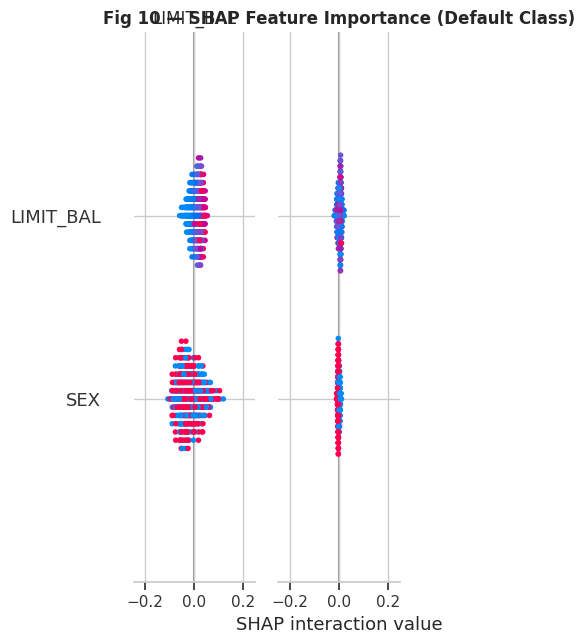

<Figure size 1000x800 with 0 Axes>

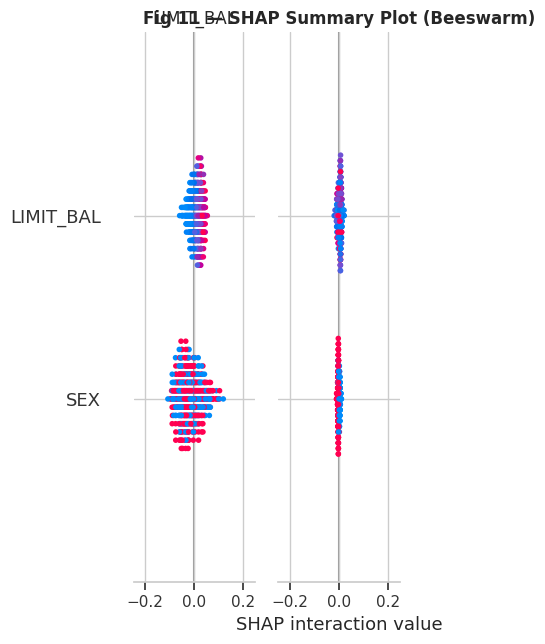

In [28]:
rng        = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_test_sc), size=min(500, len(X_test_sc)), replace=False)
X_sample   = X_test_sc[sample_idx]
feat_names = X.columns.tolist()

explainer = shap.TreeExplainer(best_after)
shap_vals  = explainer.shap_values(X_sample)


if isinstance(shap_vals, list):
    sv = shap_vals[1]
else:
    sv = shap_vals


plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_sample, feature_names=feat_names,
                  plot_type='bar', show=False)
plt.title('Fig 10 — SHAP Feature Importance (Default Class)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


plt.figure(figsize=(10, 8))
shap.summary_plot(sv, X_sample, feature_names=feat_names, show=False)
plt.title('Fig 11 — SHAP Summary Plot (Beeswarm)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ── Top-10 most important features by mean |SHAP| ─────────────────────────────
#mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)
#mean_shap=pd.Series(np.abs(sv.values).mean(axis=0),index=feat_names).sort_values(ascending=False)
#mean_shap = pd.Series(np.abs(sv.values).mean(axis=(0, 2)), index=feat_names).sort_values(ascending=False)
mean_shap = pd.Series(np.abs(sv).mean(axis=(0, 2)), index=feat_names).sort_values(ascending=False)
#mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=feat_names).sort_values(ascending=False)# 2D
print('Top 10 features by mean |SHAP| value:')
print(mean_shap.head(10).round(4).to_string())

Top 10 features by mean |SHAP| value:
PAY_0            0.0591
RISK_RATING      0.0379
PAY_2            0.0285
LIMIT_BAL_LOG    0.0198
LIMIT_BAL        0.0193
PAY_3            0.0190
PAY_AMT2         0.0164
PAY_AMT1         0.0162
PAY_AMT3         0.0161
PAY_4            0.0161
